## Chapter 1: Singular Value Decomposition

### Section 1.1: Overview

In [ ]:
# Computing SVD
import numpy as np
import pandas as pd
X = np.random.rand(5, 3) #I'm creating a random 5x3 matrix
U, S, VT = np.linalg.svd(X, full_matrices = True) #Setting full_matrices to False would give us a reduced SVD
UHat, SHat, VTHat = np.linalg.svd(X, full_matrices = False) #Here's our aforementioned Economy SVD

In [3]:
print(f"{U} \n")
print(f"{S} \n")
print(VT)

[[-0.16552205 -0.04385344  0.49020904 -0.75686943 -0.39689178]
 [-0.5065064   0.84147108  0.11349409  0.064518    0.13540392]
 [-0.53923229 -0.16902844 -0.46458322  0.1726764  -0.65954774]
 [-0.34021361 -0.34208805  0.69369489  0.53453193  0.01713117]
 [-0.55636046 -0.38001113 -0.2230785  -0.32778737  0.62357518]] 

[2.30305963 0.68564664 0.53291408] 

[[-0.57045974 -0.53615229 -0.6221868 ]
 [ 0.56670496 -0.80526751  0.17432651]
 [-0.59449237 -0.25315009  0.76321285]]


In [4]:
print(f"{UHat} \n")
print(f"{SHat} \n")
print(VTHat)

[[-0.16552205 -0.04385344  0.49020904]
 [-0.5065064   0.84147108  0.11349409]
 [-0.53923229 -0.16902844 -0.46458322]
 [-0.34021361 -0.34208805  0.69369489]
 [-0.55636046 -0.38001113 -0.2230785 ]] 

[2.30305963 0.68564664 0.53291408] 

[[-0.57045974 -0.53615229 -0.6221868 ]
 [ 0.56670496 -0.80526751  0.17432651]
 [-0.59449237 -0.25315009  0.76321285]]


### Section 5.2 SVD Image Compression
 

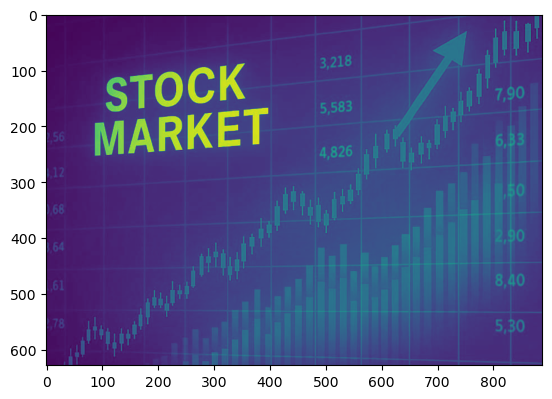

In [5]:
#First, we load the image
import matplotlib 
import matplotlib.pyplot as plt

from matplotlib.image import imread
A = imread(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\stock_market.jpg")
X = np.mean(A, -1); #Converting to grayscale
img = plt.imshow(X)

In [6]:
#import os

#print(os.getcwd())
#print(os.listdir())

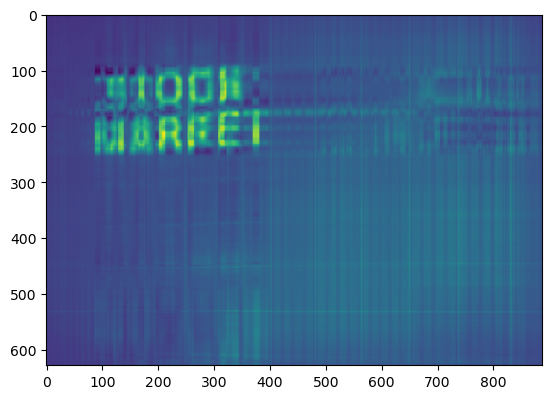

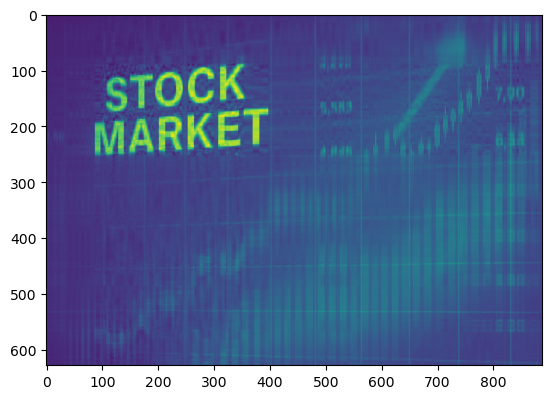

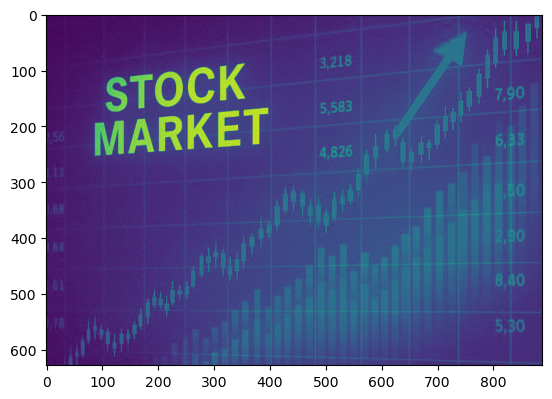

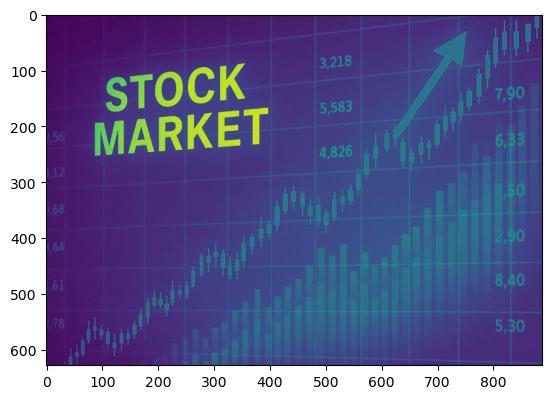

In [7]:
#Take SVD
U, S, VT = np.linalg.svd(X, full_matrices=False)
S = np.diag(S)

#Approximate matrix with truncated SVD for various r

for r in (5, 20, 100, 200):
    Xapprox = U[:, :r] @ S[0:r, :r] @ VT[:r, :]
    img = plt.imshow(Xapprox)
    plt.show()

<bound method Axes.set of <Axes: xlabel='Rank', ylabel='Cumulative Sum'>>

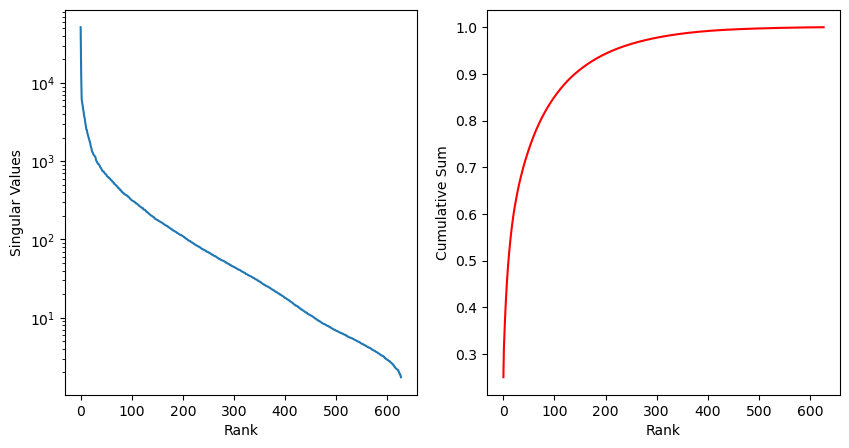

In [8]:
#Plot singular values and cumulative sum
#Create 2 graphs
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].semilogy(np.diag(S)) #Convenient for converting to log scale graph
ax[0].set_ylabel('Singular Values')
ax[0].set_xlabel('Rank')

ax[1].plot(np.cumsum(np.diag(S))/np.sum(np.diag(S)), color = 'red')
ax[1].set_ylabel('Cumulative Sum')
ax[1].set_xlabel('Rank')
ax[1].set

### Section 1.4 Pseudo-inverse

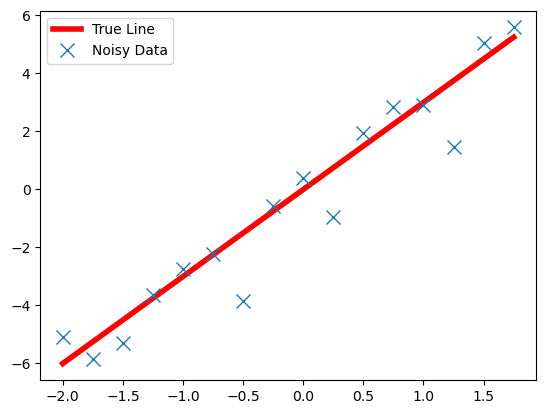

In [9]:
#Least-Squares fit of noisy data in fig 1.9

x = 3 #This is the true slope of the line

a = np.arange(-2, 2, 0.25)
a = a.reshape(-1, 1)
b = x*a + np.random.randn(*a.shape) #Adding noise to the data to simulate real-world data

plt.plot(a, x*a, 'r-', label = 'True Line', linewidth = 4)

plt.plot(a, b, 'x', label = 'Noisy Data', markersize = 10, linewidth = 6)

plt.legend()

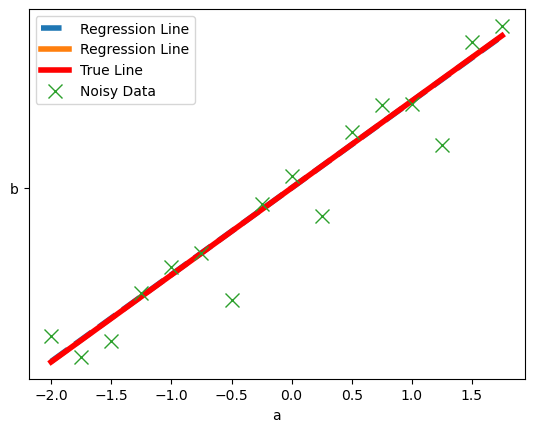

In [10]:
#Now we're going to use a least squares approximation with SVD and see how it matches up with the true line

U, S, VT = np.linalg.svd(a, full_matrices=False)
xtilde = VT.T @ np.linalg.inv(np.diag(S)) @ U.T @ b #Least Square fit using inverse solution

plt.plot(a, xtilde*a, '--', 'b', label = 'Regression Line', linewidth = 4)

#I'm now overlaying the previous graph on top just for a visual comparison of the two lines

plt.plot(a, x*a, 'r-', label = 'True Line', linewidth = 4)
plt.plot(a, b, 'x', label = 'Noisy Data', markersize = 10, linewidth = 6)

plt.xlabel('a')

plt.legend()
#You can see that the regression line is a good approximation of the true line, even with the noise in the data. This demonstrates the power of SVD.

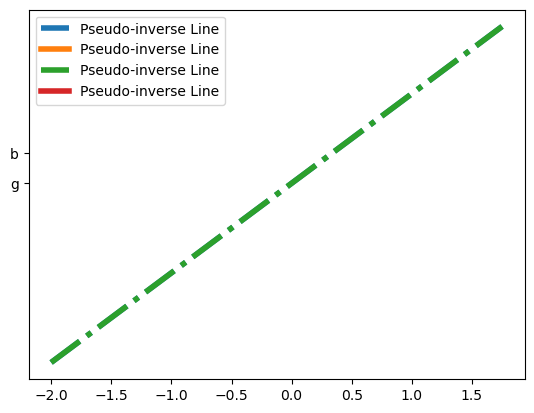

In [11]:
#Alternate least squares formulation

#Note, if x is a 1x1 matrix, then dot product and matrix multiplication are equivalent here

xtilde2 = np.linalg.pinv(a) @ b #Least Square fit using pseudo-inverse

plt.plot(a, xtilde2*a, '-.', 'g', label = 'Pseudo-inverse Line', linewidth = 4)
plt.plot(a, a @ xtilde2, '-.', 'b', label = 'Pseudo-inverse Line', linewidth = 4)

plt.legend()

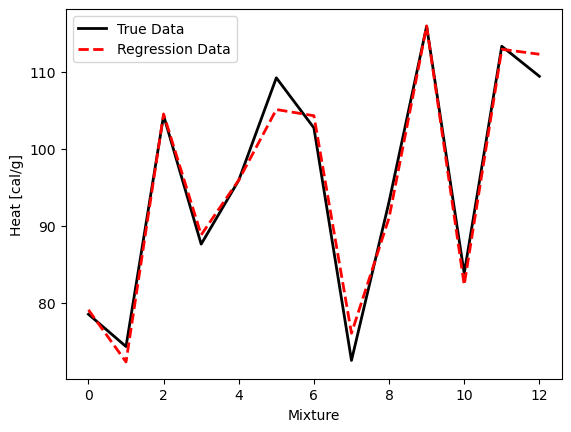

In [12]:
#Multiple linear regression for cement data

#Load dataset
A = pd.read_csv(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\Book_Data\hald_ingredients.csv", header = None)
b = pd.read_csv(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\Book_Data\hald_heat.csv", header = None)

#Using good old SVD to solve Ax = b

U, S, VT = np.linalg.svd(A, full_matrices = 0)
#x = VT.T @ np.linalg.inv(np.diag(S)) @ U.T @ b
x = np.linalg.pinv(A) @ b #pinv is much more convenient than writing ou the whole inverse solution

plt.plot(b, 'k', linewidth = 2, label = 'True Data')
plt.plot(A @ x, 'r--', linewidth = 2, label = 'Regression Data')

plt.xlabel('Mixture')
plt.ylabel('Heat [cal/g]')

plt.legend()

In [13]:
#Example 2: Determining significance of factors
    #Boston Housing Market
    #See book github, if this doesn't come up in the homework, I will work through it myself

### Section 1.5 Principal Component Analysis (PCA)

In [14]:
#Generate noisy cloud  of data
xCenter = np.array([2,1]) #center of data (Mean)
sig = np.array([2, 0.5]) #Principal axes [Directions of maximum variance]

theta = np.pi/3 #Angle of rotation of cloud
R = np.array([[np.cos(theta), -np.sin(theta)], 
            [np.sin(theta), np.cos(theta)]]) #Rotation matrix

nPoints = 10000 #Create 10,000 points in the cloud

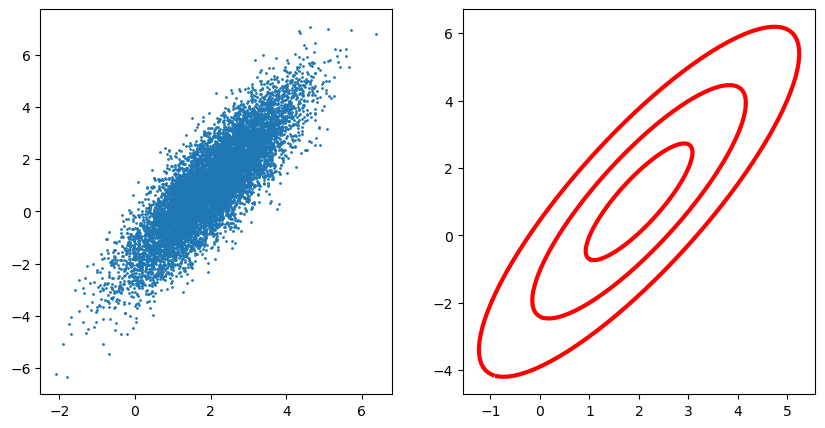

In [15]:
X = R @ np.diag(sig) @ np.random.randn(2, nPoints) + np.diag(xCenter) @ np.ones((2, nPoints)) #What I think is happening is in the first term you're 
#Creating a cloud that is stretched and compressed according to principal axes and then shifted by the center values due to the addition of the second term
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(X[0, :], X[1, :], '.', markersize = 2)

#Find principal components (SVD)
Xavg = np.mean(X, axis = 1) #Compute mean
B = X - np.tile(Xavg, (nPoints, 1)).T #Mean subtracted data

#Find Principal Components
U, S, VT = np.linalg.svd(B/np.sqrt(nPoints-1), full_matrices = False) #SVD of mean subtracted data
theta = 2 * np.pi * np.arange(0, 1, 0.01) #Create a range of angles

Xstd = U @ np.diag(S) @ np.array([np.cos(theta), np.sin(theta)]) 

ax2.plot(Xavg[0] + Xstd[0,:], Xavg[1] + Xstd[1, :], '-', color = 'red', linewidth = 3)
ax2.plot(Xavg[0] + 2 * Xstd[0,:], Xavg[1] + 2 * Xstd[1, :], '-', color = 'red', linewidth = 3)
ax2.plot(Xavg[0] + 3 * Xstd[0,:], Xavg[1] + 3 * Xstd[1, :], '-', color = 'red', linewidth = 3)


Text(0, 0.5, 'PC3')

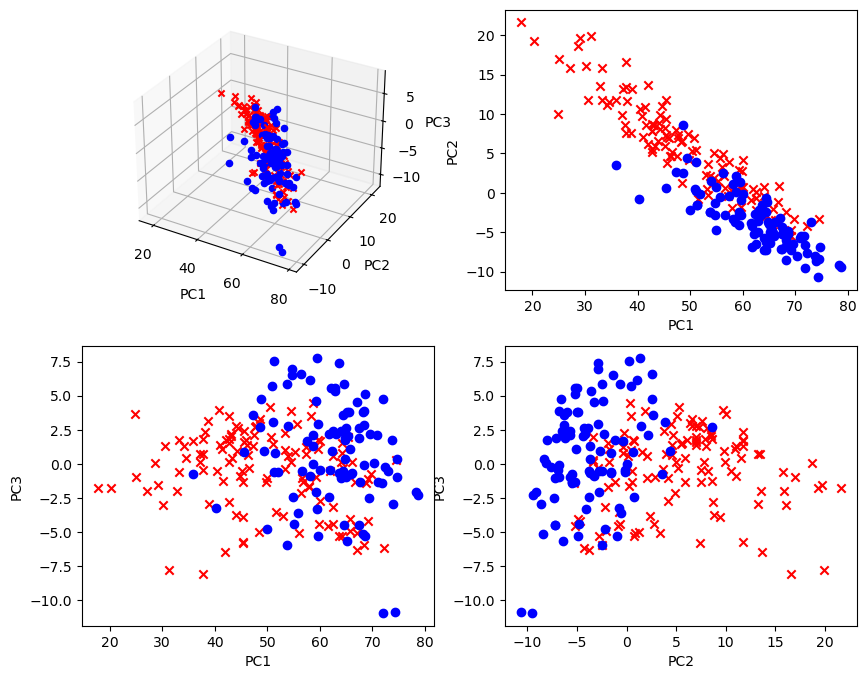

In [56]:
#Example: Computing PCA of Ovarian Cancer Dataset
fig = plt.figure(figsize=(10, 8))

ax1 = fig.add_subplot(221, projection='3d')
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

obs = pd.read_csv(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\Book_Data\ovariancancer_obs.csv")
f = pd.read_csv(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\Book_Data\ovariancancer_grp.csv")

U, S, VT = np.linalg.svd(obs, full_matrices = False)

for j in range(obs.shape[0]):
    x = VT[0, :] @ obs.iloc[j, :].T
    y = VT[1, :] @ obs.iloc[j, :].T
    z = VT[2, :] @ obs.iloc[j, :].T

    if f.iloc[j, 0] == 'Cancer': 
        ax1.scatter(x, y, z, marker = 'x', color = 'r')
        ax2.scatter(x, y, marker = 'x', color = 'r')
        ax3.scatter(x, z, marker = 'x', color = 'r')
        ax4.scatter(y, z, marker = 'x', color = 'r')
    else: 
        ax1.scatter(x, y, z, marker = 'o', color = 'b')
        ax2.scatter(x, y, marker = 'o', color = 'b')
        ax3.scatter(x, z, marker = 'o', color = 'b')
        ax4.scatter(y, z, marker = 'o', color = 'b')

ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')

ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')

ax3.set_xlabel('PC1')
ax3.set_ylabel('PC3')

ax4.set_xlabel('PC2')
ax4.set_ylabel('PC3')

It's obvious by the graphs that PC1 and PC2 have the strongest explanatory power, whereas PC3 is significantly weaker

### Section 1.6: Eigenfaces 

C:\Users\saami\AppData\Local\Temp\ipykernel_36608\3848245144.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m = int(mat_contents['m'])
C:\Users\saami\AppData\Local\Temp\ipykernel_36608\3848245144.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n = int(mat_contents['n'])


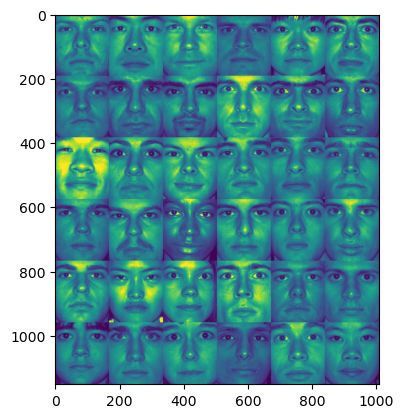

In [65]:
#Plotting image from each person in the Yale database
from scipy.io import loadmat
mat_contents = loadmat(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\Book_Data\allFaces.mat")
faces = mat_contents['faces']
m = int(mat_contents['m'])
n = int(mat_contents['n'])
nfaces = np.ndarray.flatten(mat_contents['nfaces'])

allPersons = np.zeros((n*6, m*6))
count = 0

for j in range(6):
    for k in range(6):
        allPersons[j * n : (j+1) * n, k * m : (k+1) * m] = np.reshape(faces[:, np.sum(nfaces[:count])], (m, n)).T
        count += 1

img = plt.imshow(allPersons)

In [84]:
#Computing eigenfaces on the mean-subtracted data

#We use the first 36 for training data
trainingFaces = faces[:, 0:np.sum(nfaces[0:36])]
avgFace = np.mean(trainingFaces, axis = 1) # size n*m by 1

#Compute eigenfaces on mean-subtracted training data
X = trainingFaces - np.tile(avgFace, (trainingFaces.shape[1], 1)).T

U, S, VT = np.linalg.svd(X, full_matrices = 0)
img_avg = ax1.imshow(np.reshape(avgFace, (m,n)).T)
img_u1 = ax2.imshow(np.reshape(U[:, 0], (m,n)).T)